In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')  # 0 = malignant, 1 = benign

print('Dataset shape:', X.shape)
print('Class distribution:')
print(y.value_counts().rename({0: 'Malignant', 1: 'Benign'}))

# Train/test split — stratify to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('\nTrain size:', X_train.shape, '| Test size:', X_test.shape)

Dataset shape: (569, 30)
Class distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64

Train size: (455, 30) | Test size: (114, 30)


### Defining the pipelines for each model

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Each pipeline: StandardScaler (essential for KNN and SVM) + model
models = {
    'KNN': Pipeline([('scaler', StandardScaler()),
                      ('model',  KNeighborsClassifier(n_neighbors=5))]),
    'Decision Tree': Pipeline([('scaler', StandardScaler()),
                               ('model',  DecisionTreeClassifier(random_state=42))]),
    'Random Forest': Pipeline([('scaler', StandardScaler()),
                               ('model',  RandomForestClassifier(n_estimators=100, random_state=42))]),
     'SVM': Pipeline([('scaler', StandardScaler()),
                      ('model',  SVC(kernel='rbf', probability=True, random_state=42))]),
}

### Decision Tree

In [27]:
results = []

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1 Score':  round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba), 4),
    })
    print(f'\n--- {name} ---')
    print(classification_report(y_test, y_pred, target_names=['Malignant','Benign']))

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print('\nSummary Table:')
print(results_df.to_string(index=False))


--- KNN ---
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


--- Decision Tree ---
              precision    recall  f1-score   support

   Malignant       0.85      0.93      0.89        42
      Benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114


--- Random Forest ---
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg   

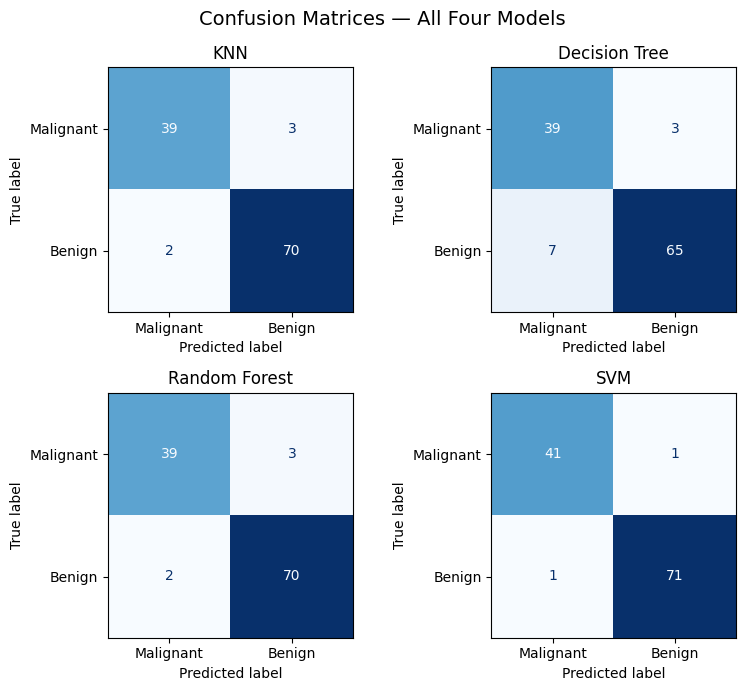

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
for ax, (name, pipeline) in zip(axes.flat, models.items()):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Malignant','Benign'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.suptitle('Confusion Matrices — All Four Models', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

In [29]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, pipeline in models.items():
    acc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
    f1_scores  = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
    auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
    cv_results.append({
        'Model':        name,
        'CV Accuracy':  f'{acc_scores.mean():.4f} ± {acc_scores.std():.4f}',
        'CV F1':        f'{f1_scores.mean():.4f} ± {f1_scores.std():.4f}',
        'CV ROC-AUC':   f'{auc_scores.mean():.4f} ± {auc_scores.std():.4f}',
    })

cv_df = pd.DataFrame(cv_results)
print('Cross-Validation Results (5-Fold):')
print(cv_df.to_string(index=False))

Cross-Validation Results (5-Fold):
        Model     CV Accuracy           CV F1      CV ROC-AUC
          KNN 0.9595 ± 0.0191 0.9679 ± 0.0158 0.9837 ± 0.0087
Decision Tree 0.9332 ± 0.0162 0.9465 ± 0.0135 0.9293 ± 0.0153
Random Forest 0.9596 ± 0.0070 0.9678 ± 0.0058 0.9873 ± 0.0128
          SVM 0.9807 ± 0.0066 0.9846 ± 0.0055 0.9954 ± 0.0049


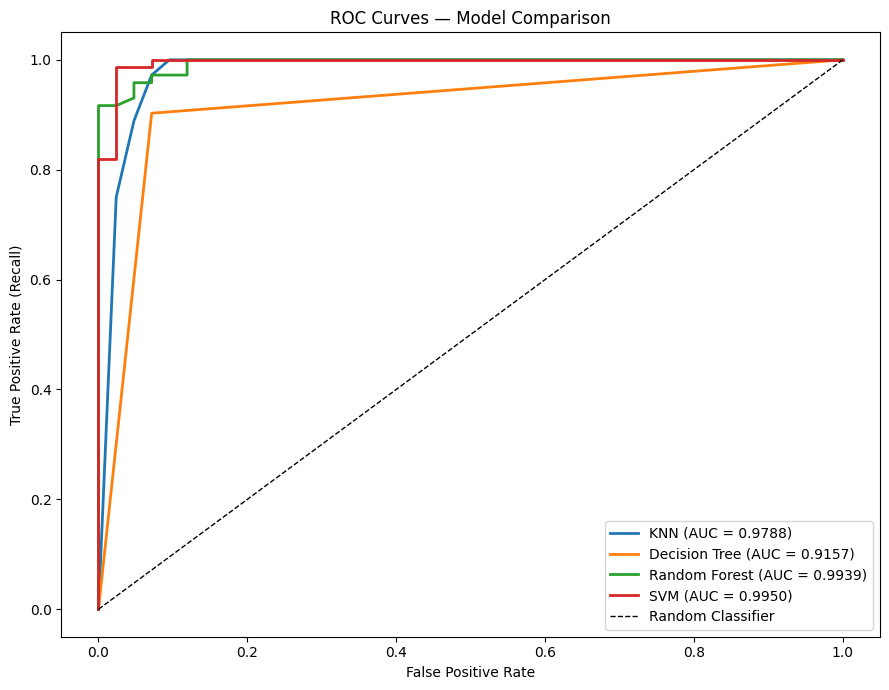

In [30]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9, 7))
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', lw=2)

plt.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()